# Exercise - Prevision the value of the stock market of Petrobras

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = '/content/drive/MyDrive/datasets/RNN/PETR4.SA2.csv'
df = pd.read_csv(path)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,13.660646,30182600
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,14.153233,30552600
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,14.174045,36141000
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,13.931217,28069600
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,13.528824,29091300
...,...,...,...,...,...,...,...
2229,2021-12-23,28.330000,28.420000,28.150000,28.330000,28.330000,28713600
2230,2021-12-27,28.320000,28.780001,28.150000,28.750000,28.750000,44227900
2231,2021-12-28,29.010000,29.280001,28.700001,28.780001,28.780001,30688100
2232,2021-12-29,28.700001,28.900000,28.420000,28.540001,28.540001,35508400


In [4]:
df[df.isna().any(axis=1)] #dont have lines with empty data

,Date,Open,High,Low,Close,Adj Close,Volume


In [5]:
prices = df['Close'] #we wiil use only the data of the Close Column

## Data Visualization

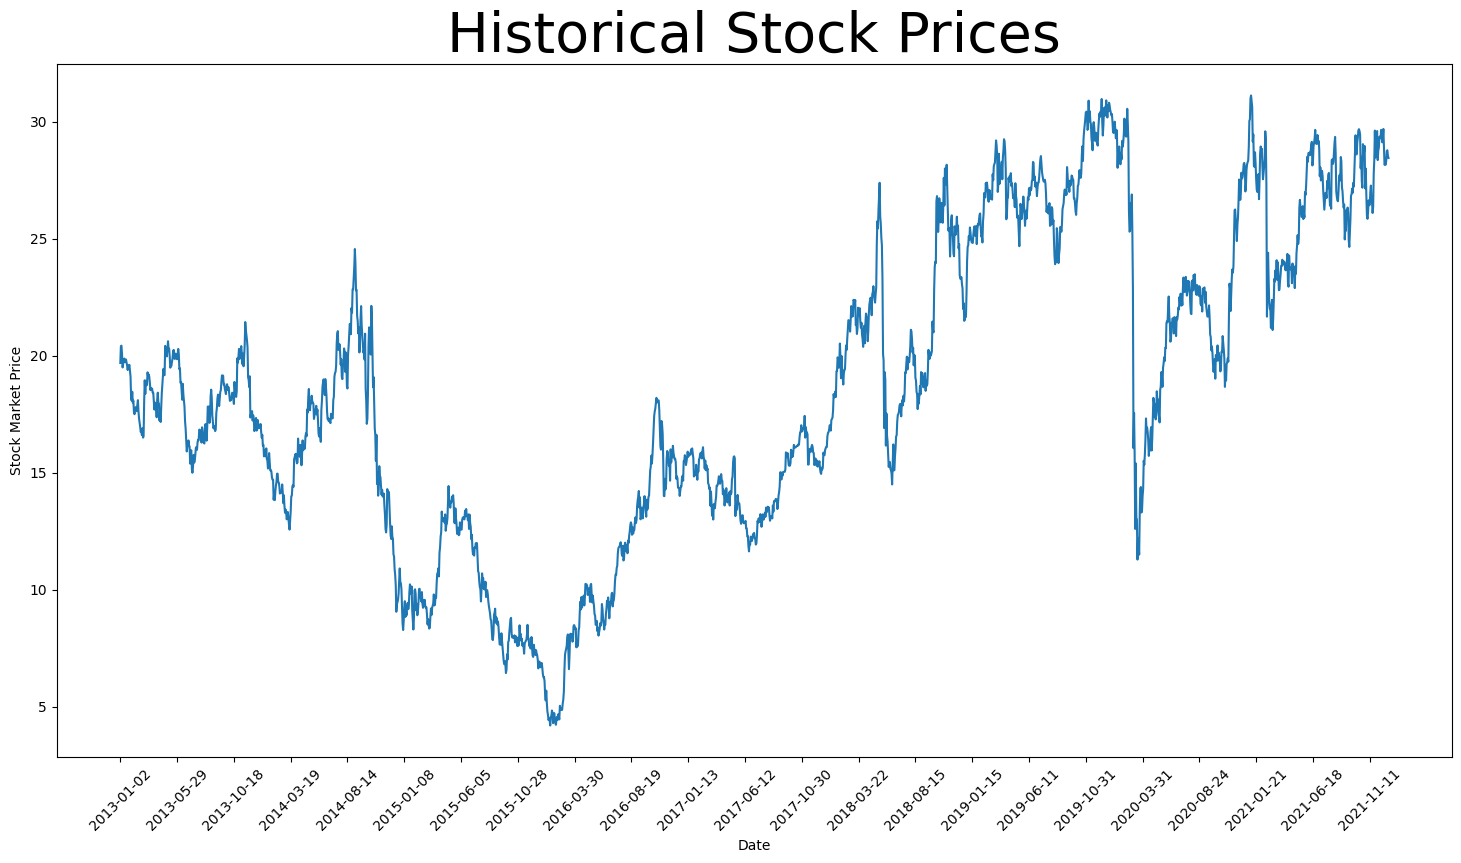

In [6]:
plt.figure(figsize= (18,9))
plt.plot(prices)
plt.xticks(range(0,df.shape[0],100), df['Date'].loc[::100], rotation = 45)
plt.xlabel("Date")
plt.ylabel("Stock Market Price")
plt.title("Historical Stock Prices", fontsize = 40)
plt.show()

## Creating the RNN

In [7]:
step_time = 20 # for the current date we will analise the last 20 days - We will build an LSTM (it theorically analyse all the memmory but we can introduce a focus period)

### Spliting Data for Train and Test

In [8]:
training_size = int(len(prices) * 0.9)
test_size = len(prices) - training_size
train_data, test_data = np.array(prices[0:training_size]), np.array(prices[training_size - step_time:])
validate_data = np.array(prices[training_size:])

### Normalizing the Data

In [9]:
scaler = MinMaxScaler(feature_range=(0,1))
train_data_norm = scaler.fit_transform(np.array(train_data).reshape(-1,1)) #reshape makes the array to like a "matrix" [[1],[2],[3],[4],...] before de array was like [1,2,3,4,...] the -1 says that you dont have a specific number of lines that you want to pack it, and the second value says how many element will have in each "matrix"
test_data_norm = scaler.transform(np.array(test_data).reshape(-1,1))
validate_data_norm = scaler.transform(np.array(validate_data).reshape(-1,1))

### Preprocessing the Data


In [10]:
# for test
x_train = []
y_train = []
for i in range(step_time, len(train_data)):
  x_train.append(train_data_norm[i-step_time:i])
  y_train.append(train_data_norm[i])

# for test
x_test = []
y_test = []
for j in range(step_time, len(test_data)):
  x_test.append(test_data_norm[j-step_time:j])
  y_test.append(test_data_norm[j])


# for validation
x_val = []
y_val = []
for i in range(step_time, len(validate_data_norm)):
  x_val.append(validate_data_norm[i-step_time:i])
  y_val.append(validate_data_norm[i])

In [21]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
x_val = np.array(x_val)
y_val = np.array(y_val)

224


### Build the RNN

In [12]:
class RNNModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers = 1):
    # input_size refers to the number of features that are joining to the RNN - We are just looking to the Close Stock Price, so Input_size = 1
    # hidden_size refers to how many neurons have in each cell

    #Atention the RNN only accepts data in the follow patern: [batch_size, Sequence Lenght, Input_size]


    super(RNNModel, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # Build the RNN
    self.rnn = nn.RNN(
        input_size= input_size,
        hidden_size= hidden_size,
        num_layers= num_layers,
        batch_first=True
    )

    #Output layer

    self.linear = nn.Linear(hidden_size,output_size)

  def forward(self,x):
    # RNN returns (output, h_n)
    rnn_out, h_n = self.rnn(x)
    # Pega a saída do ÚLTIMO passo de tempo de toda a sequência
    last_output = rnn_out[:,-1,:] #shape (batch_size, hidden_size) -> Define a many to one RNN
    output = self.linear(last_output)
    return output




In [13]:
# Testing
model = RNNModel(input_size=10, hidden_size=20, output_size=1, num_layers=2)
x = torch.randn(4,8,10) #P1 - batch_size, P2 - Sequence Lenght, P3 - Input_size
test = model(x)
test.shape # expect output: torch.size([4,5]) -> 4 (batch_size), 1 (output_size)

torch.Size([4, 1])

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
stock_model = RNNModel(input_size=1,hidden_size=16,output_size=1).to(device)


In [15]:
lossfunc = nn.MSELoss()
optim = torch.optim.Adam(stock_model.parameters(), lr = 0.002)

### Tranforming the data to Tensor

In [16]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)
x_val_tensor = torch.tensor(x_val, dtype=torch.float32, device=device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device=device)

train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
validate_dataset = TensorDataset(x_val_tensor,y_val_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)


train_dataloader = DataLoader(batch_size=32,dataset=train_dataset)
validate_dataloader = DataLoader(batch_size=32,dataset=validate_dataset)
test_dataloader = DataLoader(batch_size=32,dataset=test_dataset)

### Trainning the model

In [25]:
def train(model, dataloader, lossfunc, optimizer):
  Y_train_pred = []
  Y_train_true = []
  model.train()

  cumloss = 0.0
  for data, expect in dataloader:
    data = data.to(device)
    expect = expect.unsqueeze(1).to(device)

    pred = model(data)
    loss = lossfunc(pred, expect)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    cumloss += loss.item()
    Y_train_pred.extend(pred.detach().cpu().numpy().flatten())
    Y_train_true.extend(expect.cpu().numpy().flatten())

  return cumloss/len(dataloader), Y_train_true, Y_train_pred

def test(model, dataloader, loss_func):
  Y_test_pred = []
  Y_test_true = []
  model.eval() # semelhante ao .train(), mas é melhor para teste
  cumloss = 0.0
  with torch.no_grad(): #turn off gradients computation
    for X, y in dataloader:
      X = X.to(device)
      y = y.unsqueeze(1).to(device)

      pred = model(X)
      loss = loss_func(pred, y)

      cumloss += loss.item()

      Y_test_pred.extend(pred.detach().cpu().numpy().flatten())
      Y_test_true.extend(y.cpu().numpy().flatten())
  return cumloss/len(dataloader), Y_test_pred, Y_test_true

In [26]:
epochs = 100
train_loss_arr = []
vali_loss_arr = []
for t in range(1, epochs + 1):
  train_loss, train_true, train_expected = train(stock_model, train_dataloader, lossfunc, optim)
  val_loss, val_pred, val_expect = test(stock_model, validate_dataloader, lossfunc)
  train_loss_arr.append(train_loss)
  vali_loss_arr.append(val_loss)
  if (t % 10 == 0):
    print(f'Epoch {t} - Error: {train_loss}')
    print(f'Epoch {t} - Error: {val_loss}')

test_loss, test_pred, test_expect = test(stock_model, test_dataloader, lossfunc)
print(f'Test Error: {test_loss}')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 1, 1])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([6, 1, 1])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([12, 1, 1])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F

Epoch 10 - Error: 0.006071260782875239
Epoch 10 - Error: 0.003121313655615917
Epoch 20 - Error: 0.006029385582743478
Epoch 20 - Error: 0.003231010940258524
Epoch 30 - Error: 0.005913744605745056
Epoch 30 - Error: 0.0032097897908118156
Epoch 40 - Error: 0.006111102703485697
Epoch 40 - Error: 0.0032456044905952047
Epoch 50 - Error: 0.005944852532434558
Epoch 50 - Error: 0.003237138078215399
Epoch 60 - Error: 0.005945362206104966
Epoch 60 - Error: 0.0032967481363032547
Epoch 70 - Error: 0.005893447178615523
Epoch 70 - Error: 0.0031948545947670937
Epoch 80 - Error: 0.0058317246139123445
Epoch 80 - Error: 0.003225181659217924
Epoch 90 - Error: 0.005903673041353209
Epoch 90 - Error: 0.003190558037853667
Epoch 100 - Error: 0.0059214625710858
Epoch 100 - Error: 0.0032748132694645654
Test Error: 0.004927050455340317


In [38]:
pred_matriz = np.array(test_pred).reshape(-1,1) #Tranforma os valores em uma matriz de uma coluna
expect_matriz = np.array(test_expect).reshape(-1,1)

p_pred_non_norm = scaler.inverse_transform(pred_matriz) # Desnormaliza os valores
p_expect_non_norm = scaler.inverse_transform(expect_matriz)

p_final_pred = p_pred_non_norm.flatten()
p_final_expect = p_expect_non_norm.flatten()

<Figure size 640x480 with 0 Axes>

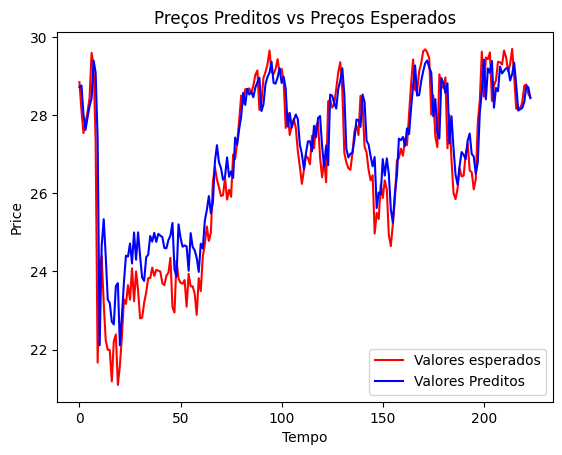

<Figure size 640x480 with 0 Axes>

In [39]:
epoch = range(0, len(p_final_expect))
plt.plot(epoch, p_final_expect, "r", label="Valores esperados")
plt.plot(epoch, p_final_pred, "b", label="Valores Preditos")
plt.xlabel("Tempo")
plt.ylabel("Price")
plt.title("Preços Preditos vs Preços Esperados")
plt.legend()
plt.figure()

<Figure size 640x480 with 0 Axes>

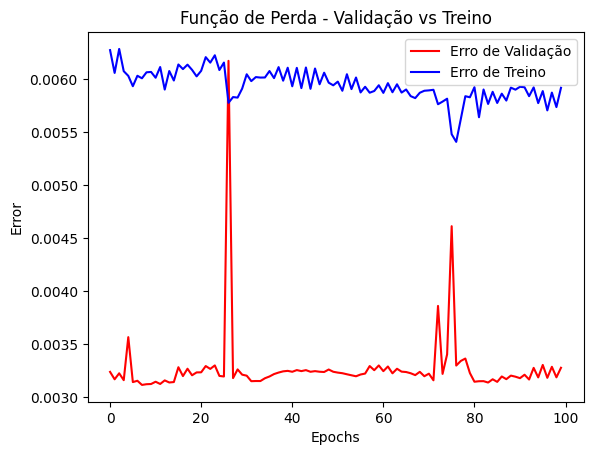

<Figure size 640x480 with 0 Axes>

In [43]:
epoc = range(epochs)
plt.plot(epoc, vali_loss_arr, "r", label="Erro de Validação")
plt.plot(epoc, train_loss_arr, "b", label="Erro de Treino")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Função de Perda - Validação vs Treino")
plt.legend()
plt.figure()

## Creating LSTM - Trying to Predict future data

In [44]:
class LSTMModel(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers = 1):
    super(LSTMModel, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.lstm = nn.LSTM(
        input_size = input_size,
        hidden_size=hidden_size,
        num_layers = num_layers,
        batch_first=True
    )

    self.linear = nn.Linear(in_features=hidden_size, out_features=output_size)

  def forward(self,x):
    lstm_out, (h_n, c_n) = self.lstm(x)
    lstm_output = lstm_out[:,-1,:]
    return self.linear(lstm_output)

In [61]:
# Testing
lstm_model = LSTMModel(input_size=10, hidden_size=20, output_size=5, num_layers=2)
x = torch.randn(4, 8, 10)  # (batch_size=4, seq_length=8, input_size=10)
output = lstm_model(x)
print("LSTM Output shape:", output.shape)
print("LSTM output sample:", output[0])
stock_model_lstm = LSTMModel(input_size=1,hidden_size=16,output_size=1).to(device)

LSTM Output shape: torch.Size([4, 5])
LSTM output sample: tensor([0.0254, 0.2049, 0.1791, 0.0370, 0.0562], grad_fn=<SelectBackward0>)


In [62]:
stock_model_lstm.eval()
predicted_days = 5

pred_y = len(y_test)

x_predicted = x_test[0:1].copy()
projection = []

with torch.no_grad():
  for d in range(pred_y):
    x_tensor = torch.tensor(x_predicted, dtype=torch.float32,device=device)
    next_pred = stock_model_lstm(x_tensor)
    pred_value = next_pred.item()
    projection.append(pred_value)

    temp = x_predicted[0].flatten()
    temp = np.delete(temp, 0)
    temp = np.append(temp, pred_value)
    step = len(temp)
    x_predicted[0] = temp.reshape(step,1)

projection_matrix = np.array(projection).reshape(-1, 1)
future_projection = scaler.inverse_transform(projection_matrix).flatten()
y_test_matrix = np.array(y_test).reshape(-1, 1)
real_values = scaler.inverse_transform(y_test_matrix).flatten()


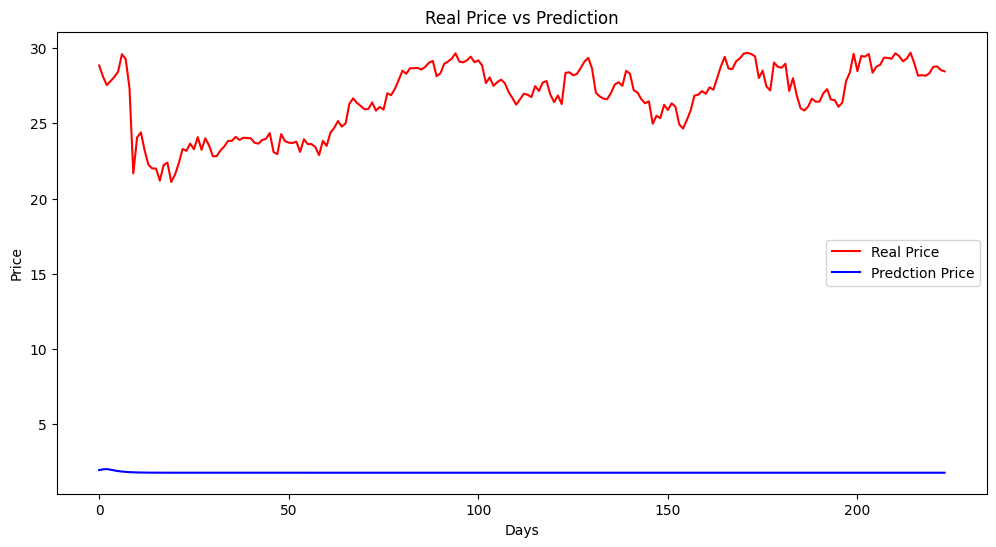

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(real_values, color='red', label='Real Price')
plt.plot(future_projection, color='blue', label='Predction Price')
plt.title('Real Price vs Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()